In [1049]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from Bootstraping import *
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

# defining models

In [1378]:
class ReadoutNet(nn.Module):
    def __init__(self,nro):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4*nro, 24),
            nn.ReLU(),
            nn.Linear(24, 46),
            nn.ReLU(),
            nn.Linear(46, 24),
            nn.ReLU(),
            nn.Linear(24, 4)
        )

    def forward(self, x):
        # x: (batch, 4, 300)
        x = x.view(x.shape[0], -1)

        logits = self.net(x)
        pred = torch.argmax(logits, dim=1)

        return logits, pred
    
    
class SmallReadoutCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(4, 24, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),      # (batch, 24, 1) -> (batch, 24)
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, 4)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        pred = torch.argmax(logits, dim=1)
        return logits, pred


class CNN(nn.Module):
    def __init__(self):
        super().__init__()


        # Input: 4 readout frequencies, 500 time steps
        self.conv1 = nn.Conv1d(4, 32, kernel_size=9, padding=4)   # small first layer
        self.pool1 = nn.AvgPool1d(kernel_size=4)                  # 500 -> 250

        self.conv2 = nn.Conv1d(32, 32, kernel_size=9, padding=4) # moderate second layer
        self.pool2 = nn.AvgPool1d(kernel_size=2)                  # 250 -> 125

        # Optional third conv for richer features
        self.conv3 = nn.Conv1d(32, 16, kernel_size=9, padding=4)

        # Global average pooling over time dimension
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Fully connected layer to classify into n_classes
        self.fc = nn.Linear(16, 4)

    def forward(self, x):
        # x: (batch_size, 4, 500)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))

        x = self.global_pool(x)   # (batch_size, 32, 1)
        x = x.squeeze(-1)         # (batch_size, 32)

        x = self.fc(x)            # (batch_size, n_classes)
        pred = torch.argmax(x, dim=1)

        return x,pred












class ReadoutCNN_bigger(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(4, 32, kernel_size=10, padding=5)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=9, padding=4)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 4)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))

        x = self.pool(x).squeeze(-1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        logits = self.fc3(x)
        pred = torch.argmax(logits, dim=1)
        return logits, pred

# Defining DataSet Structure

In [1125]:


class ReadoutDataset_estimator_(Dataset):
    def __init__(self, X, Y):
        denom = torch.arange(1, X.shape[-1] + 1, dtype=torch.float32).view(1, 1, X.shape[-1])
        self.X = torch.tensor(X, dtype=torch.float32)/ denom
        x = self.X
        std = x.std(dim=(0, 2), keepdim=True)
        self.X = x/std
        self.X = x / (x.mean(dim=(1,2), keepdim=True) + 1e-8) 
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
    

class ReadoutDataset_differential_(Dataset):
    def __init__(self, X, Y):
        denom = torch.arange(1, X.shape[-1] + 1, dtype=torch.float32).view(1, 1, X.shape[-1])
        dx = torch.tensor( X[:,0,:] + X[:,1,:] - X[:,2,:] - X[:,3,:])
        dy = torch.tensor( X[:,0,:] + X[:,2,:] - X[:,3,:] - X[:,1,:])
        
        self.X = torch.zeros((X.shape[0],2,X.shape[2]))      
        self.X[:,0,:] = dx
        self.X[:,1,:] = dy
        self.X = self.X/denom
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [ ]:
dark_click_rate = 0.01
signal_click_rate = 0.01
nro = 300
samples = np.random.poisson(dark_click_rate, size=nro)
data_points = 10

values = [0, 1, 2]
fast_cross_relax = 300
slow_cross_relax = 3000
probs = [1-1/300, 1/300, 1/3000]   # must sum to 1

x = np.random.choice(values, p=probs, size=nro)

X = np.zeros(data_points,4,300)


In [1321]:
import numpy as np

values = [0, 1, 2]

def get_trace(
    nro,
    init_state=0,
    dark_rate=0.163,
    signal_rate=0.14,
    dark_sigma=0.02,
    signal_sigma=0.02,
    probs=np.array([1 - 1/300 - 1/3000, 1/300, 1/3000])
):
    # sample flips
    flips = np.random.choice(values, size=nro, p=probs)

    # sample Gaussian-distributed Poisson rates at each time step
    dark_K = np.random.normal(loc=dark_rate, scale=dark_sigma, size=(4, nro))
    signal_K = np.random.normal(loc=signal_rate, scale=signal_sigma, size=nro)

    # Poisson rates must be positive
    dark_K = np.clip(dark_K, 1e-9, None)
    signal_K = np.clip(signal_K, 1e-9, None)

    # now sample counts from Poisson with those time-dependent rates
    dark = np.random.poisson(dark_K)
    signal = np.random.poisson(signal_K)

    counts = dark.copy()
    s = init_state

    for t in range(nro):
        counts[s, t] += signal[t]

        f = flips[t]

        if f == 1:
            if s == 0:
                s = 1
            elif s == 1:
                s = 0
            elif s == 2:
                s = 3
            else:
                s = 2

        elif f == 2:
            if s == 0:
                s = 2
            elif s == 2:
                s = 0
            elif s == 1:
                s = 3
            else:
                s = 1

    return np.cumsum(counts, axis=1)

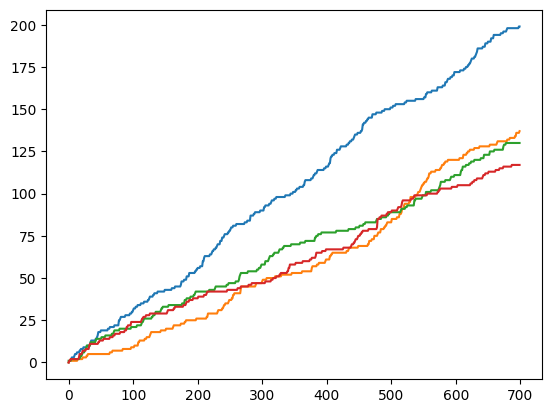

In [ ]:
x = get_trace(700)

plt.plot(x[0])
plt.plot(x[1])
plt.plot(x[2])
plt.plot(x[3])
X_data = np.array([get_trace(300,init_state = k%4) for k in range(10000)])
Y_data = np.array([k%4 for k in range(10000)])


    

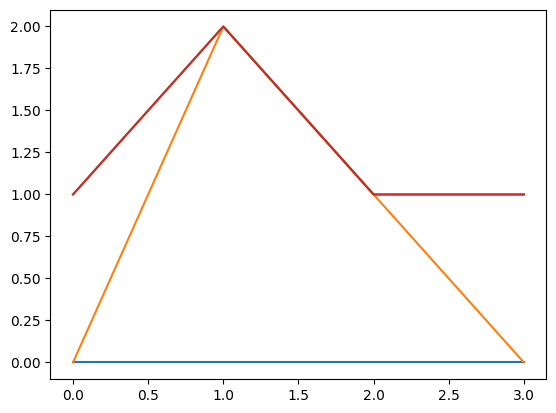

In [ ]:
plt.plot(meas_counts[0,0,0])
plt.plot(meas_counts[0,0,1])
plt.plot(meas_counts[0,0,2])
plt.plot(meas_counts[0,0,3])



In [ ]:
dataset = ReadoutDataset(X_data, Y_data)
loader = DataLoader(dataset, batch_size=400, shuffle=True)

In [ ]:
# model = ReadoutNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
losses = []
for epoch in range(1000):
    for x_batch, y_batch in loader:

        logits = model(x_batch)

        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(f"epoch {epoch}, loss {loss.item():.4f}")

epoch 0, loss 0.2555
epoch 1, loss 0.2935
epoch 2, loss 0.2690
epoch 3, loss 0.1974
epoch 4, loss 0.2344
epoch 5, loss 0.2971
epoch 6, loss 0.2365
epoch 7, loss 0.2599
epoch 8, loss 0.2506
epoch 9, loss 0.2874
epoch 10, loss 0.2381
epoch 11, loss 0.2437
epoch 12, loss 0.2769
epoch 13, loss 0.2694
epoch 14, loss 0.2522
epoch 15, loss 0.2714
epoch 16, loss 0.2559
epoch 17, loss 0.2419
epoch 18, loss 0.2576
epoch 19, loss 0.2181
epoch 20, loss 0.2096
epoch 21, loss 0.2386
epoch 22, loss 0.2456
epoch 23, loss 0.2650
epoch 24, loss 0.2612
epoch 25, loss 0.2727
epoch 26, loss 0.2889
epoch 27, loss 0.2916
epoch 28, loss 0.2738
epoch 29, loss 0.2354
epoch 30, loss 0.2993
epoch 31, loss 0.2751
epoch 32, loss 0.2514
epoch 33, loss 0.2739
epoch 34, loss 0.2185
epoch 35, loss 0.2581
epoch 36, loss 0.2032
epoch 37, loss 0.2318
epoch 38, loss 0.2034
epoch 39, loss 0.2401
epoch 40, loss 0.2592
epoch 41, loss 0.2636
epoch 42, loss 0.3132
epoch 43, loss 0.2199
epoch 44, loss 0.2509
epoch 45, loss 0.240

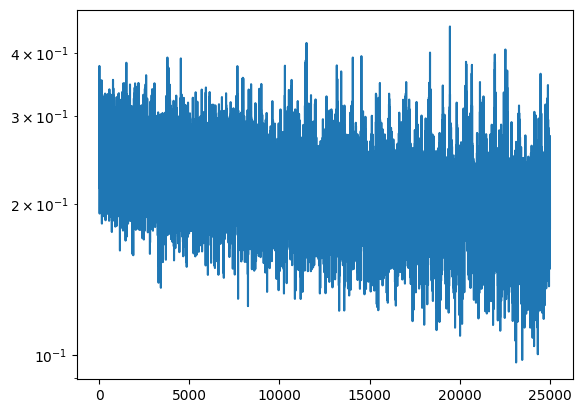

In [ ]:
plt.plot(losses)
plt.yscale('log')

In [ ]:

def save_model_with_accuracy(model, accuracy,name):
    filename = name + f"model_acc_{accuracy:.4f}.pt"
    torch.save(model.state_dict(), filename)
    print(f"saved {filename}")

# Load Measurement Data

In [ ]:
names = ['20260313235440__NuclearReadout_With_tracking_XY_read_out.hdf5','20260313223620__NuclearReadout_With_tracking_XY_read_out.hdf5','20260313122250__NuclearReadout_With_tracking_XY_read_out.hdf5','20260314203749__NuclearReadout_With_tracking_XY_read_out.hdf5','20260316000131__NuclearReadout_With_tracking_XY_read_out.hdf5' ]

In [1343]:

dirpath = 'Z:/SPIN-001/Run2 [BFp4]/NuclearReadout_With_tracking_XY_read_out/'
signal = load_h5_to_dic(dirpath + names[5])[0]



IndexError: list index out of range

In [1372]:
X_data = []
Y_data = []

for meas_id in [1]:
    signal = load_h5_to_dic(dirpath + names[meas_id])[0]
    clicksX = signal['clicksX']
    print(signal['clicksX'].shape)
    clicks = clicksX[:,:,:,:]
    r = 500


    meas_counts = np.array([np.array([clicks[:,:,:nro,i].sum(-1) for nro in range(r)]) for i in range(4)])
    meas_counts = meas_counts.transpose(2,0, 1, 3)

    for i in range(4):
        X_data.extend(meas_counts[:,i,:,:])
        Y_data.extend(np.repeat(i,meas_counts.shape[0]))
        
     
X_data = np.array(X_data)
Y_data = np.array(Y_data)


(180, 4, 500, 4)


In [1352]:
X_data = X_data.transpose(0,2,1)


In [ ]:
nro_delta_x = 490
nro_delta_y = 102
figs = []



fig,ax = plt.subplots(2,2,figsize = (14,8))


clicksX = signal['clicksX']

nuclear_nro = clicksX.shape[2]



avg = clicksX.shape[0]
nb_prep_states = clicksX.shape[1]
xnro = clicksX.shape[2]

print('clicks shape is ',clicksX.shape)  #clicks shape is  (43, 4, 50, 4)

delta_X = np.zeros((nb_prep_states,avg))
delta_X_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y = np.zeros((nb_prep_states,avg))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

buffer1 =[]
buffer2 =[]
for prepped_state in [0,1,2,3]:
    
    
    dx_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,1] - clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3]
    dy_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3] - clicksX[:,prepped_state,:,1]
    
    dx_nro = X_data[]
    dy_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3] - clicksX[:,prepped_state,:,1]

    delta_X_nro[prepped_state] = dx_nro
    delta_Y_nro[prepped_state] = dy_nro
    delta_X[prepped_state] = dx_nro[:,:nro_delta_x].sum(1)
    delta_Y[prepped_state] = dy_nro[:,:nro_delta_y].sum(1)

    # delta_X[prepped_state,:] = np.where(np.abs(delta_X[prepped_state,:])>5,delta_X[prepped_state,:],0)
    # delta_Y[prepped_state,:] = np.where(np.abs(delta_Y[prepped_state,:])>5,delta_Y[prepped_state,:],0)

    ax[0,0].scatter(delta_X[prepped_state,:],delta_Y[prepped_state,:],label = f'state {prepped_state}',alpha = 0.2)
    

ax[0,0].set_xlabel('Delta X  = (0+1) - (2+3)')
ax[0,0].set_ylabel('Delta Y  = (0+2) - (1+3)')
ax[0,0].set_title(f'ReadOut Distribution for NRO_X = {nro_delta_x} and NRO_Y = {nro_delta_y}')
ax[0,0].legend()

states_points  = np.array([np.stack((delta_X[i], delta_Y[i]),axis= 1) for i in range(4)])
states_points_nro  = np.array([np.stack((delta_X_nro[i,:], delta_Y_nro[i,:]),axis= 1) for i in range(4)])
print("state points shape is ", states_points_nro.shape)
labels = np.zeros(states_points.shape[:2], dtype=int)-1
labels_nro = np.zeros(states_points.shape[:2], dtype=int)-1
fidelity = np.zeros((4,nuclear_nro))
for i, state  in enumerate(states_points):
    
    
    for nro in range(1,nuclear_nro):
        
        _dx = X_data[i]    states_points_nro[i][:, 0,:nro].sum(1)
        _dy = states_points_nro[i][:, 1,:nro].sum(1)
        labels_nro[i, (_dx > 0) & (_dy > 0)] = 0
        labels_nro[i, (_dx < 0) & (_dy > 0)] = 2
        labels_nro[i, (_dx > 0) & (_dy< 0)] = 1
        labels_nro[i, (_dx < 0) & (_dy< 0)] = 3
        
        a = np.array([np.sum(labels_nro[i,:]==0),np.sum(labels_nro[i,:]==1),np.sum(labels_nro[i,:]==2),np.sum(labels_nro[i,:]==3)])
        
        fidelity[i,nro] = a[i]/np.sum(a)
        
    labels[i, (state[:, 0] > 0) & (state[:, 1] > 0)] = 0
    labels[i, (state[:, 0] < 0) & (state[:, 1] > 0)] = 2
    labels[i, (state[:, 0] > 0) & (state[:, 1] < 0)] = 1
    labels[i, (state[:, 0] < 0) & (state[:, 1] < 0)] = 3
    
    
    ax[1,0].plot(np.arange(1,nuclear_nro),fidelity[i,1:],label = f'state {i} max fidelity {np.max(fidelity[i,:]):.3f} for nro = {np.argmax(fidelity[i,:])}')
    
sum = (fidelity[0,1:] + fidelity[1,1:] + fidelity[2,1:] + fidelity[3,1:])/4
ax[1,0].plot(np.arange(1,nuclear_nro),sum,label = f'state {i} max fidelity of sum {np.max(sum):.3f} for nro = {np.argmax(sum)}')

ax[1,0].set_xlabel('NRO')
ax[1,0].set_ylabel('fidelity')
ax[1,0].set_title('4 state readout fidelities')
ax[1,0].legend()
coords = np.concatenate(states_points_nro)
x_pfidelity = []
x_nfidelity = []
y_pfidelity = []
y_nfidelity = []

fidelity_map = np.zeros((nuclear_nro,nuclear_nro))

# for nro_x in range(nuclear_nro):
#     print(nro_x)
#     for nro_y in range(nuclear_nro):
        
#         _dx = states_points_nro[:, :, 0,:nro_x].sum(2)
#         _dy = states_points_nro[:, :, 1,:nro_y].sum(2)
        
#         f0 = np.sum((_dx[0] > 0) & (_dy[0] > 0))/_dx[0].shape[0]
#         f1 =  np.sum((_dx[2] < 0) & (_dy[2] > 0))/_dx[2].shape[0]
#         f2 =  np.sum((_dx[1] > 0) & (_dy[1] < 0))/_dx[1].shape[0]
#         f3 =  np.sum((_dx[3] < 0) & (_dy[3] < 0))/_dx[3].shape[0]
        
#         fidelity_map[nro_x,nro_y] = (f0+f1+f2+f3)/4

best_nros = np.argmax(fidelity_map)+1
        
        

for nro in range(nuclear_nro):
    
    
    _dx = states_points_nro[:,:, 0,:nro].sum(-1)
    _dy = states_points_nro[:,:, 1,:nro].sum(-1)

    x_pfidelity.append((np.sum(_dx[0,:]>0) + np.sum(_dx[1,:]>0))/(_dx[0,:].shape[0]+_dx[1,:].shape[0]))
    x_nfidelity.append((np.sum(_dx[2,:]<0) + np.sum(_dx[3,:]<0))/(_dx[2,:].shape[0]+_dx[3,:].shape[0]))
    
    y_pfidelity.append((np.sum(_dy[0,:]>0) + np.sum(_dy[2,:]>0))/(_dy[0,:].shape[0]+_dy[2,:].shape[0]))
    y_nfidelity.append((np.sum(_dy[1,:]<0) + np.sum(_dy[3,:]<0))/(_dy[1,:].shape[0]+_dy[3,:].shape[0]))
    

ax[1,1].plot(np.arange(nuclear_nro),x_pfidelity, label = f'X positive, max fidelity : {np.max(x_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_pfidelity)]+1}',color = colors[4])
ax[1,1].plot(np.arange(nuclear_nro),x_nfidelity, label = f'X negative, max fidelity : {np.max(x_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_nfidelity)]+1}',color = colors[5])
ax[1,1].plot(np.arange(nuclear_nro),y_pfidelity, label = f'Y positive, max fidelity : {np.max(y_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_pfidelity)]+1}',color = colors[6])
ax[1,1].plot(np.arange(nuclear_nro),y_nfidelity, label = f'Y negative, max fidelity : {np.max(y_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_nfidelity)]+1}',color = colors[7])
ax[1,1].set_xlabel('NRO')
ax[1,1].set_ylabel('fidelity')
ax[1,1].set_title(f'2 state readout fidelities, best parameters {best_nros}')
ax[1,1].legend()


Plot_State_prep_matrix2(labels,ax[0,1])
ax[0,1].set_title('State Fidelity Matrix')
fig.tight_layout()
plt.show()

clicks shape is  (433, 4, 700, 4)
state points shape is  (4, 433, 2, 700)


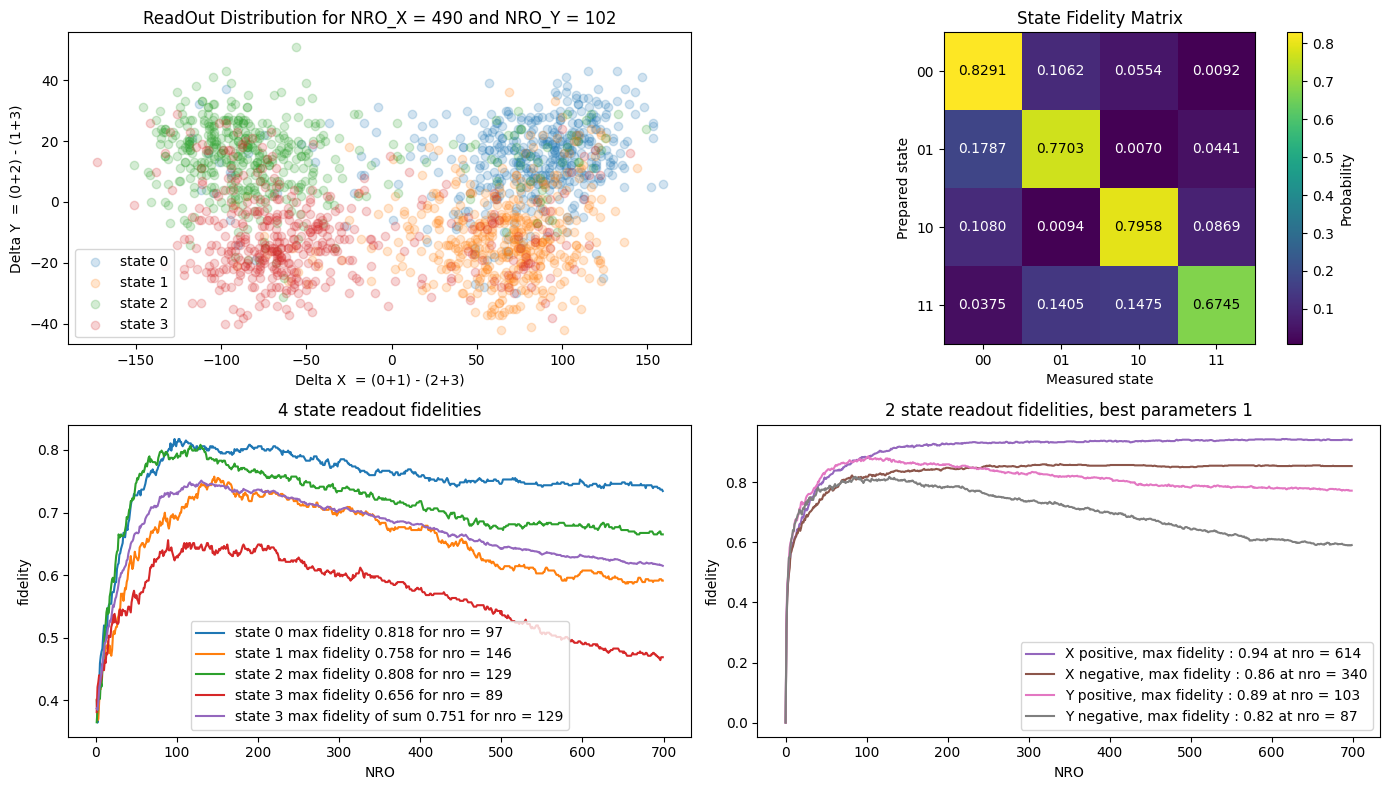

In [1346]:
nro_delta_x = 490
nro_delta_y = 102
figs = []



fig,ax = plt.subplots(2,2,figsize = (14,8))


clicksX = signal['clicksX']

nuclear_nro = clicksX.shape[2]



avg = clicksX.shape[0]
nb_prep_states = clicksX.shape[1]
xnro = clicksX.shape[2]

print('clicks shape is ',clicksX.shape)  #clicks shape is  (43, 4, 50, 4)

delta_X = np.zeros((nb_prep_states,avg))
delta_X_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y = np.zeros((nb_prep_states,avg))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

buffer1 =[]
buffer2 =[]
for prepped_state in [0,1,2,3]:
    
    
    dx_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,1] - clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3]
    dy_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3] - clicksX[:,prepped_state,:,1]

    delta_X_nro[prepped_state] = dx_nro
    delta_Y_nro[prepped_state] = dy_nro
    delta_X[prepped_state] = dx_nro[:,:nro_delta_x].sum(1)
    delta_Y[prepped_state] = dy_nro[:,:nro_delta_y].sum(1)

    # delta_X[prepped_state,:] = np.where(np.abs(delta_X[prepped_state,:])>5,delta_X[prepped_state,:],0)
    # delta_Y[prepped_state,:] = np.where(np.abs(delta_Y[prepped_state,:])>5,delta_Y[prepped_state,:],0)

    ax[0,0].scatter(delta_X[prepped_state,:],delta_Y[prepped_state,:],label = f'state {prepped_state}',alpha = 0.2)
    

ax[0,0].set_xlabel('Delta X  = (0+1) - (2+3)')
ax[0,0].set_ylabel('Delta Y  = (0+2) - (1+3)')
ax[0,0].set_title(f'ReadOut Distribution for NRO_X = {nro_delta_x} and NRO_Y = {nro_delta_y}')
ax[0,0].legend()

states_points  = np.array([np.stack((delta_X[i], delta_Y[i]),axis= 1) for i in range(4)])
states_points_nro  = np.array([np.stack((delta_X_nro[i,:], delta_Y_nro[i,:]),axis= 1) for i in range(4)])
print("state points shape is ", states_points_nro.shape)
labels = np.zeros(states_points.shape[:2], dtype=int)-1
labels_nro = np.zeros(states_points.shape[:2], dtype=int)-1
fidelity = np.zeros((4,nuclear_nro))
for i, state  in enumerate(states_points):
    
    
    for nro in range(1,nuclear_nro):
        
        _dx = states_points_nro[i][:, 0,:nro].sum(1)
        _dy = states_points_nro[i][:, 1,:nro].sum(1)
        labels_nro[i, (_dx > 0) & (_dy > 0)] = 0
        labels_nro[i, (_dx < 0) & (_dy > 0)] = 2
        labels_nro[i, (_dx > 0) & (_dy< 0)] = 1
        labels_nro[i, (_dx < 0) & (_dy< 0)] = 3
        
        a = np.array([np.sum(labels_nro[i,:]==0),np.sum(labels_nro[i,:]==1),np.sum(labels_nro[i,:]==2),np.sum(labels_nro[i,:]==3)])
        
        fidelity[i,nro] = a[i]/np.sum(a)
        
    labels[i, (state[:, 0] > 0) & (state[:, 1] > 0)] = 0
    labels[i, (state[:, 0] < 0) & (state[:, 1] > 0)] = 2
    labels[i, (state[:, 0] > 0) & (state[:, 1] < 0)] = 1
    labels[i, (state[:, 0] < 0) & (state[:, 1] < 0)] = 3
    
    
    ax[1,0].plot(np.arange(1,nuclear_nro),fidelity[i,1:],label = f'state {i} max fidelity {np.max(fidelity[i,:]):.3f} for nro = {np.argmax(fidelity[i,:])}')
    
sum = (fidelity[0,1:] + fidelity[1,1:] + fidelity[2,1:] + fidelity[3,1:])/4
ax[1,0].plot(np.arange(1,nuclear_nro),sum,label = f'state {i} max fidelity of sum {np.max(sum):.3f} for nro = {np.argmax(sum)}')

ax[1,0].set_xlabel('NRO')
ax[1,0].set_ylabel('fidelity')
ax[1,0].set_title('4 state readout fidelities')
ax[1,0].legend()
coords = np.concatenate(states_points_nro)
x_pfidelity = []
x_nfidelity = []
y_pfidelity = []
y_nfidelity = []

fidelity_map = np.zeros((nuclear_nro,nuclear_nro))

# for nro_x in range(nuclear_nro):
#     print(nro_x)
#     for nro_y in range(nuclear_nro):
        
#         _dx = states_points_nro[:, :, 0,:nro_x].sum(2)
#         _dy = states_points_nro[:, :, 1,:nro_y].sum(2)
        
#         f0 = np.sum((_dx[0] > 0) & (_dy[0] > 0))/_dx[0].shape[0]
#         f1 =  np.sum((_dx[2] < 0) & (_dy[2] > 0))/_dx[2].shape[0]
#         f2 =  np.sum((_dx[1] > 0) & (_dy[1] < 0))/_dx[1].shape[0]
#         f3 =  np.sum((_dx[3] < 0) & (_dy[3] < 0))/_dx[3].shape[0]
        
#         fidelity_map[nro_x,nro_y] = (f0+f1+f2+f3)/4

best_nros = np.argmax(fidelity_map)+1
        
        

for nro in range(nuclear_nro):
    
    
    _dx = states_points_nro[:,:, 0,:nro].sum(-1)
    _dy = states_points_nro[:,:, 1,:nro].sum(-1)

    x_pfidelity.append((np.sum(_dx[0,:]>0) + np.sum(_dx[1,:]>0))/(_dx[0,:].shape[0]+_dx[1,:].shape[0]))
    x_nfidelity.append((np.sum(_dx[2,:]<0) + np.sum(_dx[3,:]<0))/(_dx[2,:].shape[0]+_dx[3,:].shape[0]))
    
    y_pfidelity.append((np.sum(_dy[0,:]>0) + np.sum(_dy[2,:]>0))/(_dy[0,:].shape[0]+_dy[2,:].shape[0]))
    y_nfidelity.append((np.sum(_dy[1,:]<0) + np.sum(_dy[3,:]<0))/(_dy[1,:].shape[0]+_dy[3,:].shape[0]))
    

ax[1,1].plot(np.arange(nuclear_nro),x_pfidelity, label = f'X positive, max fidelity : {np.max(x_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_pfidelity)]+1}',color = colors[4])
ax[1,1].plot(np.arange(nuclear_nro),x_nfidelity, label = f'X negative, max fidelity : {np.max(x_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_nfidelity)]+1}',color = colors[5])
ax[1,1].plot(np.arange(nuclear_nro),y_pfidelity, label = f'Y positive, max fidelity : {np.max(y_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_pfidelity)]+1}',color = colors[6])
ax[1,1].plot(np.arange(nuclear_nro),y_nfidelity, label = f'Y negative, max fidelity : {np.max(y_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_nfidelity)]+1}',color = colors[7])
ax[1,1].set_xlabel('NRO')
ax[1,1].set_ylabel('fidelity')
ax[1,1].set_title(f'2 state readout fidelities, best parameters {best_nros}')
ax[1,1].legend()


Plot_State_prep_matrix2(labels,ax[0,1])
ax[0,1].set_title('State Fidelity Matrix')
fig.tight_layout()
plt.show()

# get simulated Data

## Gaussian distributed 

In [1322]:
Nb_sims = 100_000
nro = 500

dark_rate=  np.random.normal(0.17,0.05,Nb_sims)
dark_rate = np.clip(dark_rate, 0.001, 0.5)

signal_rate= np.random.normal(0.16,0.5,Nb_sims)
signal_rate = np.clip(signal_rate, 0.001, 0.5)

a=  np.random.normal(400,150,Nb_sims)
a = np.clip(a, 250, 600)

b =  np.random.normal(1000,200,Nb_sims)
b = np.clip(b, 800, 4000)

probs = np.array([1-1/a-1/b,1/a,1/b])

X_data_sim = np.array([get_trace(nro,init_state = k%4,signal_rate = signal_rate[k],dark_rate=dark_rate[k],probs = probs[:,k]) for k in range(Nb_sims)])
Y_data_sim = np.array([k%4 for k in range(Nb_sims)])

KeyboardInterrupt: 

## equally distributed 

In [1324]:
Nb_sims = 50_000
nro = 500

dark_rate = np.random.uniform(0.01, 0.24, Nb_sims)
signal_rate = np.random.uniform(0.01, 0.24, Nb_sims)

a = np.random.uniform(50, 1000, Nb_sims)
b = np.random.uniform(1000, 6000, Nb_sims)

probs = np.array([1 - 1/a - 1/b, 1/a, 1/b])

X_data_sim = np.array([get_trace(nro,init_state = k%4,signal_rate = signal_rate[k],dark_rate=dark_rate[k],probs = probs[:,k]) for k in range(Nb_sims)])
Y_data_sim = np.array([k%4 for k in range(Nb_sims)])

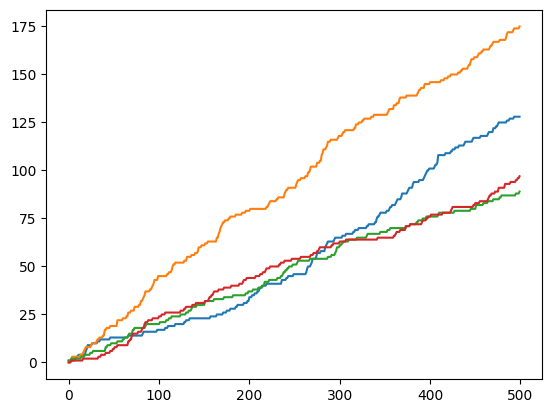

In [1315]:
i = np.random.choice(np.arange(Nb_sims))

plt.plot(X_data_sim[i,0,:])
plt.plot(X_data_sim[i,1,:])
plt.plot(X_data_sim[i,2,:])
plt.plot(X_data_sim[i,3,:])



# Plot simulated with real data 

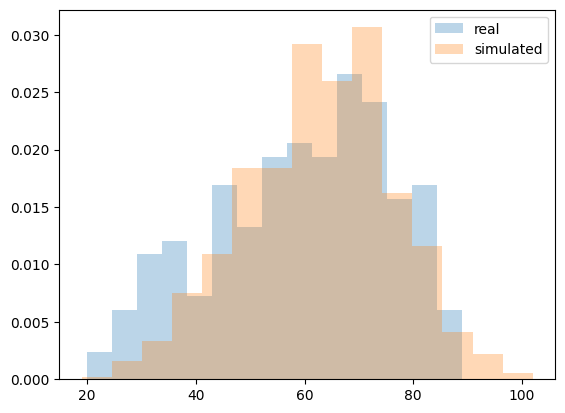

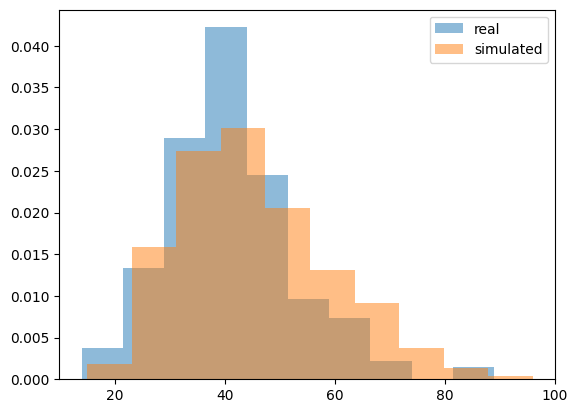

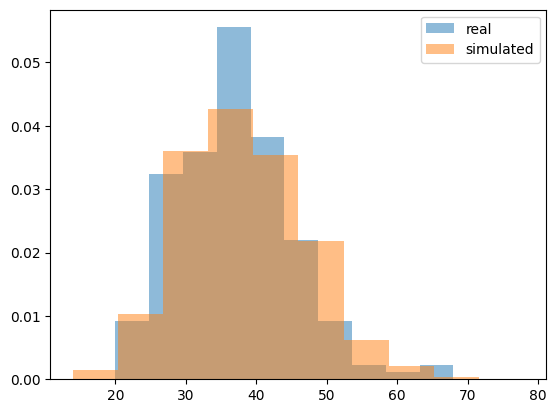

In [1230]:
plt.hist(X_data[Y_data ==0,0,200],density=True,label = 'real',alpha = 0.3,bins = 15)
plt.hist(X_data_sim[Y_data_sim ==0,0,200],density=True,label = 'simulated',alpha = 0.3,bins = 15)
plt.legend()

plt.figure()
plt.hist(X_data[Y_data ==1,0,200],density=True,label = 'real',alpha = 0.5)
plt.hist(X_data_sim[Y_data_sim ==1,0,200],density=True,label = 'simulated',alpha = 0.5)
plt.legend()


plt.figure()
plt.hist(X_data[Y_data ==0,3,200],density=True,label = 'real',alpha = 0.5)
plt.hist(X_data_sim[Y_data_sim ==0,3,200],density=True,label = 'simulated',alpha = 0.5)
plt.legend()


# Generate the datasets 

In [1351]:
X_data_sim.shape

(50000, 4, 500)

In [1365]:

# split
X_train_real, X_test_real, Y_train_real, Y_test_real = train_test_split(
    X_data, Y_data, test_size=0.9, random_state=42, stratify=Y_data
)

X_train_sim, X_test_sim, Y_train_sim, Y_test_sim = train_test_split(
    X_data_sim, Y_data_sim, test_size=0.2, random_state=42, stratify=Y_data_sim
)


# X_train = X_train_real
# Y_train = Y_train_real
X_train = np.concatenate((X_train_real,X_data_sim))
Y_train = np.concatenate((Y_train_real,Y_data_sim))

# datasets
train_sim_dataset = ReadoutDataset_estimator_(X_train, Y_train)
test_real_dataset = ReadoutDataset_estimator_(X_test_real, Y_test_real)
test_sim_dataset = ReadoutDataset_estimator_(X_test_sim, Y_test_sim)
batch_size = 2000
# loaders
train_loader = DataLoader(train_sim_dataset, batch_size=batch_size, shuffle=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=200, shuffle=True)
test_sim_loader = DataLoader(test_sim_dataset, batch_size=1000, shuffle=True)

# Training 

In [1379]:
train_losses = []
test_real_losses = []
test_sim_losses = []

train_accs = []
test_sim_accs = []
test_real_accs = []

# model = ReadoutNet(nro = 700)
model = ReadoutNet(nro = 500)
model = CNN()
learning_rate = 0.5e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

n_epochs = 5000

for epoch in range(n_epochs):
    # -----------------
    # training
    # -----------------
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_loader:
        logits,pred = model(x_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y_batch)
        train_correct += (pred == y_batch).sum().item()
        train_total += len(y_batch)

    train_loss /= train_total
    train_acc = train_correct / train_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -----------------
    # testing
    # -----------------
    model.eval()
    test_real_loss ,test_sim_loss = 0,0
    test_real_correct , test_sim_correct = 0,0
    test_real_total,test_sim_total = 0,0

    with torch.no_grad():
        for x_batch, y_batch in test_real_loader:
            logits, pred = model(x_batch)
            loss = criterion(logits, y_batch)

            test_real_loss += loss.item() * len(y_batch)
            test_real_correct += (pred == y_batch).sum().item()
            test_real_total += len(y_batch)

        test_real_loss /= test_real_total
        test_real_acc = test_real_correct / test_real_total

        test_real_losses.append(test_real_loss)
        test_real_accs.append(test_real_acc)
            
        for x_batch, y_batch in test_sim_loader:
            logits, pred = model(x_batch)
            loss = criterion(logits, y_batch)

            test_sim_loss += loss.item() * len(y_batch)
            test_sim_correct += (pred == y_batch).sum().item()
            test_sim_total += len(y_batch)

        test_sim_loss /= test_sim_total
        test_sim_acc = test_sim_correct / test_sim_total

        test_sim_losses.append(test_sim_loss)
        test_sim_accs.append(test_sim_acc)

    print(
        f"epoch {epoch+1:02d} | "
        f"train loss {train_loss:.4f} acc {100*train_acc:.2f}% | "
        f"test sim loss {test_sim_loss:.4f} acc {100*test_sim_acc:.2f}% | "
        f"test real loss {test_real_loss:.4f} acc {100*test_real_acc:.2f}"
    )



epoch 01 | train loss 1.2776 acc 49.42% | test sim loss 1.0307 acc 72.83% | test real loss 1.1187 acc 69.13
epoch 02 | train loss 0.7727 acc 75.12% | test sim loss 0.6366 acc 75.31% | test real loss 0.7308 acc 73.50
epoch 03 | train loss 0.6343 acc 75.82% | test sim loss 0.6225 acc 75.41% | test real loss 0.7199 acc 74.10
epoch 04 | train loss 0.6259 acc 75.82% | test sim loss 0.6205 acc 75.51% | test real loss 0.7169 acc 73.80
epoch 05 | train loss 0.6207 acc 76.11% | test sim loss 0.6129 acc 75.80% | test real loss 0.7128 acc 74.08
epoch 06 | train loss 0.6156 acc 76.27% | test sim loss 0.6094 acc 75.88% | test real loss 0.7114 acc 74.21
epoch 07 | train loss 0.6133 acc 76.35% | test sim loss 0.6049 acc 76.22% | test real loss 0.7131 acc 74.05
epoch 08 | train loss 0.6087 acc 76.60% | test sim loss 0.6001 acc 76.27% | test real loss 0.7096 acc 74.29
epoch 09 | train loss 0.6062 acc 76.69% | test sim loss 0.5963 acc 76.74% | test real loss 0.7107 acc 74.35
epoch 10 | train loss 0.6032

KeyboardInterrupt: 

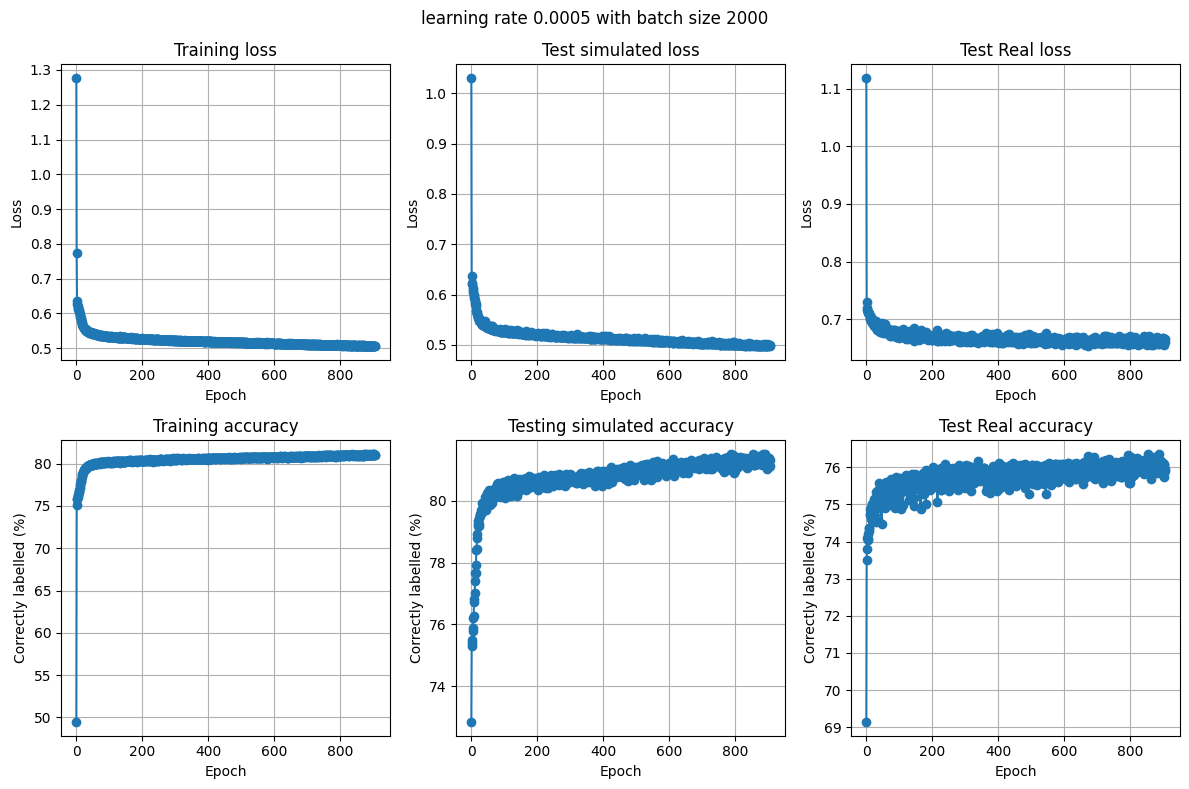

In [1380]:
# -----------------
# plots
# -----------------
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

epochs = range(1, len(train_losses) + 1)


ax[0, 0].plot(epochs, train_losses, marker='o')
ax[0, 0].set_title("Training loss")
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].set_ylabel("Loss")
ax[0, 0].grid(True)

epochs = range(1, len(test_sim_losses) +1)

ax[0, 1].plot(epochs, test_sim_losses, marker='o')
ax[0, 1].set_title("Test simulated loss")
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].set_ylabel("Loss")
ax[0, 1].grid(True)

epochs = range(1, len(test_real_losses) +1)

ax[0, 2].plot(epochs, test_real_losses, marker='o')
ax[0, 2].set_title("Test Real loss")
ax[0, 2].set_xlabel("Epoch")
ax[0, 2].set_ylabel("Loss")
ax[0, 2].grid(True)

epochs = range(1, len(100 * torch.tensor(train_accs)) +1)

ax[1, 0].plot(epochs, 100 * torch.tensor(train_accs), marker='o')
ax[1, 0].set_title("Training accuracy")
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].set_ylabel("Correctly labelled (%)")
ax[1, 0].grid(True)

epochs = range(1, len( 100 * torch.tensor(test_sim_accs)) +1)


ax[1, 1].plot(epochs, 100 * torch.tensor(test_sim_accs), marker='o')
ax[1, 1].set_title("Testing simulated accuracy")
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].set_ylabel("Correctly labelled (%)")
ax[1, 1].grid(True)

epochs = range(1, len( 100 * torch.tensor(test_real_accs)) +1)

ax[1, 2].plot(epochs, 100 * torch.tensor(test_real_accs), marker='o')
ax[1, 2].set_title("Test Real accuracy")
ax[1, 2].set_xlabel("Epoch")
ax[1, 2].set_ylabel("Correctly labelled (%)")
ax[1, 2].grid(True)

plt.suptitle(f'learning rate {learning_rate} with batch size {batch_size}')
plt.tight_layout()
plt.show()

# Saving   

In [ ]:
save_model_with_accuracy(model,test_real_acc,'normalisation_77')

saved normalisation_77model_acc_0.7569.pt


# Simple testing

In [ ]:
class ReadoutNet2(nn.Module):
    def __init__(self,nro):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4*nro, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        # x: (batch, 4, 300)
        x = x.view(x.shape[0], -1)

        logits = self.net(x)
        pred = torch.argmax(logits, dim=1)

        return logits, pred
    
model = ReadoutNet2(500)

In [ ]:
denom = torch.arange(1, X_data.shape[-1]+1, dtype=torch.float32).view(1, 1, 500)
torch.tensor(X_data[a]).unsqueeze(0)

tensor([[[  0,   1,   1,  ...,  73,  73,  73],
         [  0,   1,   3,  ..., 103, 103, 103],
         [  0,   0,   0,  ...,  81,  81,  82],
         [  0,   1,   2,  ..., 137, 137, 137]]])

In [ ]:
torch.arange(1, X_data.shape[-1]+1, dtype=torch.float32).view(1, 1, 500).shape

torch.Size([1, 1, 500])

In [ ]:
model(torch.tensor(X_data[a] , dtype=torch.float32).unsqueeze(0).contiguous())

(tensor([[ 0.6218,  0.4480,  1.8869, -2.5076]], grad_fn=<AddmmBackward0>),
 tensor([2]))

674


Text(0, 0.5, 'counts')

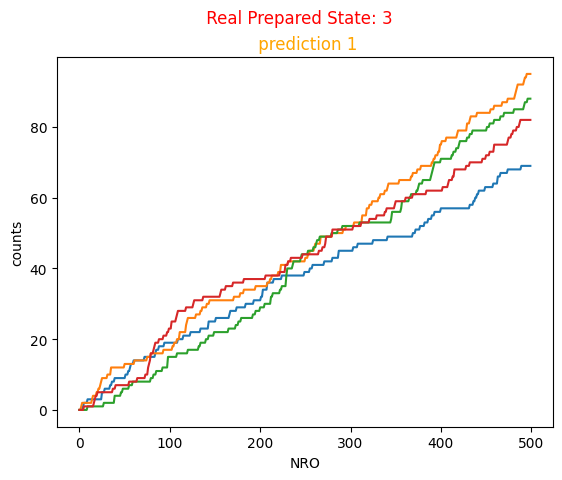

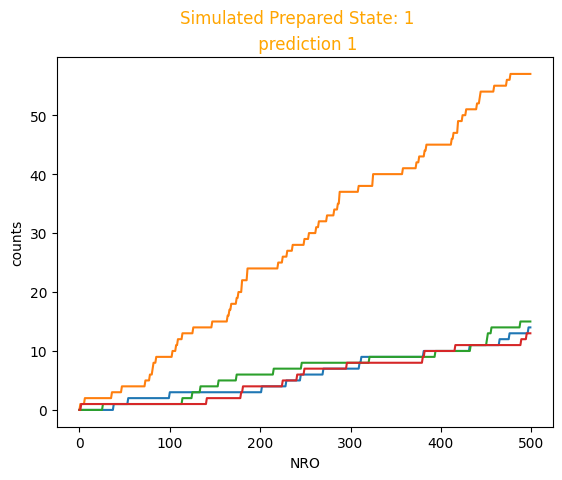

In [1403]:

colors = ['blue','orange','green','red']

a = np.random.choice(np.arange(Y_data.shape[0]))
b = np.random.choice(np.arange(Y_data_sim.shape[0]))

print(a)
model.eval()
with torch.no_grad():
    denom = torch.arange(1, X_data.shape[-1]+1, dtype=torch.float32).view(1, 1, 500)
    out_real,pred_real = model(torch.tensor(X_data[a]).unsqueeze(0).contiguous()/denom)
    out_sim,pred_sim = model(torch.tensor(X_data_sim[b]).unsqueeze(0)/denom)

for i in range(4):
    plt.plot(X_data[a,i,:])
plt.suptitle(f' Real Prepared State: {Y_data[a]}', color = colors[Y_data[a]])
plt.title(f' prediction {pred_real.item()}', color = colors[pred_real])
plt.xlabel('NRO')
plt.ylabel('counts')

plt.figure()
for i in range(4):
    plt.plot(X_data_sim[b,i,:])
plt.suptitle(f'Simulated Prepared State: {Y_data_sim[b]}', color = colors[Y_data_sim[b]])
plt.title(f' prediction {pred_sim.item()}', color = colors[pred_sim])
plt.xlabel('NRO')
plt.ylabel('counts')

In [ ]:
correct = 0
false = 0

for a in range(X_data_real.shape[0]):

    model.eval()
    with torch.no_grad():
        denom = torch.arange(1, 701, dtype=torch.float32).view(1, 1, 700)
        out,pred = model(torch.tensor(X_data_sim[a]).unsqueeze(0)/denom)

    if pred.item() == Y_data_sim[a]:
        correct+=1
        
        
print('fidelity is ', correct/X_data_sim.shape[0])

NameError: name 'X_data_real' is not defined

In [ ]:
X_data.shape

(720, 4, 500)

# Get Fidelity Matrix

# Using Dx DY

In [1327]:
def Plot_State_prep_matrix2(labels,ax):
    
    state_matrix = np.zeros((4, 4))

    for i in range(4):
        for j in range(4):
            state_matrix[i, j] = (labels[i]==j).sum(0)/np.sum((labels[i]==0) | (labels[i]==1) | (labels[i]==2) | (labels[i]==3))
                
    labels = ['00', '01', '10', '11']  # adjust if different ordering

    im = ax.imshow(state_matrix)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Probability")

    # Axis ticks and labels
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Measured state")
    ax.set_ylabel("Prepared state")

    # Annotate values inside squares
    for i in range(state_matrix.shape[0]):
        for j in range(state_matrix.shape[1]):
            value = state_matrix[i, j]
            ax.text(j, i,
            f"{value:.4f}",
                        ha="center",
                        va="center",
                        color="white" if value < 0.5 else "black")

    ax.set_aspect("equal")

clicks shape is  (180, 4, 500, 4)
state points shape is  (4, 180, 2, 500)


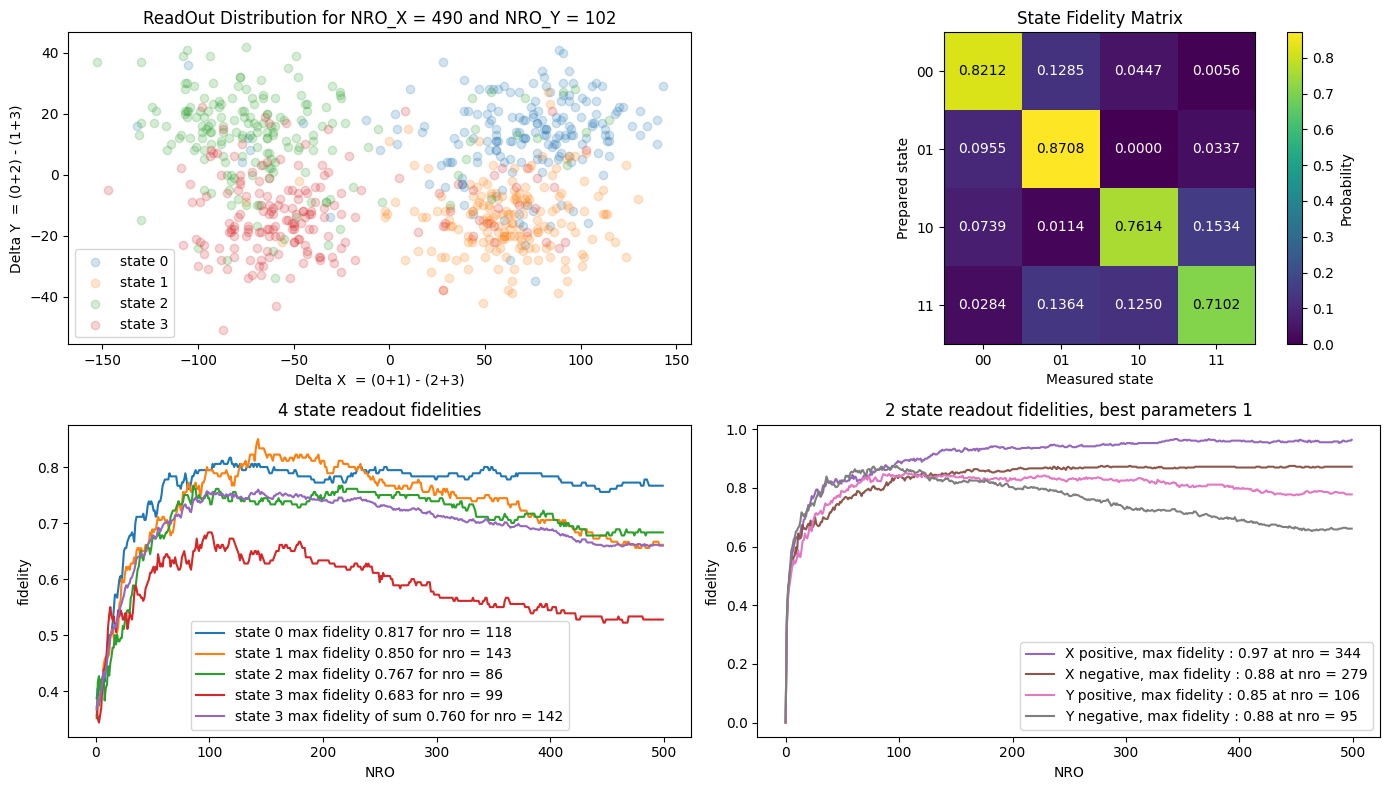

In [1328]:
nro_delta_x = 490
nro_delta_y = 102
figs = []



fig,ax = plt.subplots(2,2,figsize = (14,8))


clicksX = signal['clicksX']

nuclear_nro = clicksX.shape[2]



avg = clicksX.shape[0]
nb_prep_states = clicksX.shape[1]
xnro = clicksX.shape[2]

print('clicks shape is ',clicksX.shape)  #clicks shape is  (43, 4, 50, 4)

delta_X = np.zeros((nb_prep_states,avg))
delta_X_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y = np.zeros((nb_prep_states,avg))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

buffer1 =[]
buffer2 =[]
for prepped_state in [0,1,2,3]:
    
    
    dx_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,1] - clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3]
    dy_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3] - clicksX[:,prepped_state,:,1]

    delta_X_nro[prepped_state] = dx_nro
    delta_Y_nro[prepped_state] = dy_nro
    delta_X[prepped_state] = dx_nro[:,:nro_delta_x].sum(1)
    delta_Y[prepped_state] = dy_nro[:,:nro_delta_y].sum(1)

    # delta_X[prepped_state,:] = np.where(np.abs(delta_X[prepped_state,:])>5,delta_X[prepped_state,:],0)
    # delta_Y[prepped_state,:] = np.where(np.abs(delta_Y[prepped_state,:])>5,delta_Y[prepped_state,:],0)

    ax[0,0].scatter(delta_X[prepped_state,:],delta_Y[prepped_state,:],label = f'state {prepped_state}',alpha = 0.2)
    

ax[0,0].set_xlabel('Delta X  = (0+1) - (2+3)')
ax[0,0].set_ylabel('Delta Y  = (0+2) - (1+3)')
ax[0,0].set_title(f'ReadOut Distribution for NRO_X = {nro_delta_x} and NRO_Y = {nro_delta_y}')
ax[0,0].legend()

states_points  = np.array([np.stack((delta_X[i], delta_Y[i]),axis= 1) for i in range(4)])
states_points_nro  = np.array([np.stack((delta_X_nro[i,:], delta_Y_nro[i,:]),axis= 1) for i in range(4)])
print("state points shape is ", states_points_nro.shape)
labels = np.zeros(states_points.shape[:2], dtype=int)-1
labels_nro = np.zeros(states_points.shape[:2], dtype=int)-1
fidelity = np.zeros((4,nuclear_nro))
for i, state  in enumerate(states_points):
    
    
    for nro in range(1,nuclear_nro):
        
        _dx = states_points_nro[i][:, 0,:nro].sum(1)
        _dy = states_points_nro[i][:, 1,:nro].sum(1)
        labels_nro[i, (_dx > 0) & (_dy > 0)] = 0
        labels_nro[i, (_dx < 0) & (_dy > 0)] = 2
        labels_nro[i, (_dx > 0) & (_dy< 0)] = 1
        labels_nro[i, (_dx < 0) & (_dy< 0)] = 3
        
        a = np.array([np.sum(labels_nro[i,:]==0),np.sum(labels_nro[i,:]==1),np.sum(labels_nro[i,:]==2),np.sum(labels_nro[i,:]==3)])
        
        fidelity[i,nro] = a[i]/np.sum(a)
        
    labels[i, (state[:, 0] > 0) & (state[:, 1] > 0)] = 0
    labels[i, (state[:, 0] < 0) & (state[:, 1] > 0)] = 2
    labels[i, (state[:, 0] > 0) & (state[:, 1] < 0)] = 1
    labels[i, (state[:, 0] < 0) & (state[:, 1] < 0)] = 3
    
    
    ax[1,0].plot(np.arange(1,nuclear_nro),fidelity[i,1:],label = f'state {i} max fidelity {np.max(fidelity[i,:]):.3f} for nro = {np.argmax(fidelity[i,:])}')
    
sum = (fidelity[0,1:] + fidelity[1,1:] + fidelity[2,1:] + fidelity[3,1:])/4
ax[1,0].plot(np.arange(1,nuclear_nro),sum,label = f'state {i} max fidelity of sum {np.max(sum):.3f} for nro = {np.argmax(sum)}')

ax[1,0].set_xlabel('NRO')
ax[1,0].set_ylabel('fidelity')
ax[1,0].set_title('4 state readout fidelities')
ax[1,0].legend()
coords = np.concatenate(states_points_nro)
x_pfidelity = []
x_nfidelity = []
y_pfidelity = []
y_nfidelity = []

fidelity_map = np.zeros((nuclear_nro,nuclear_nro))

# for nro_x in range(nuclear_nro):
#     print(nro_x)
#     for nro_y in range(nuclear_nro):
        
#         _dx = states_points_nro[:, :, 0,:nro_x].sum(2)
#         _dy = states_points_nro[:, :, 1,:nro_y].sum(2)
        
#         f0 = np.sum((_dx[0] > 0) & (_dy[0] > 0))/_dx[0].shape[0]
#         f1 =  np.sum((_dx[2] < 0) & (_dy[2] > 0))/_dx[2].shape[0]
#         f2 =  np.sum((_dx[1] > 0) & (_dy[1] < 0))/_dx[1].shape[0]
#         f3 =  np.sum((_dx[3] < 0) & (_dy[3] < 0))/_dx[3].shape[0]
        
#         fidelity_map[nro_x,nro_y] = (f0+f1+f2+f3)/4

best_nros = np.argmax(fidelity_map)+1
        
        

for nro in range(nuclear_nro):
    
    
    _dx = states_points_nro[:,:, 0,:nro].sum(-1)
    _dy = states_points_nro[:,:, 1,:nro].sum(-1)

    x_pfidelity.append((np.sum(_dx[0,:]>0) + np.sum(_dx[1,:]>0))/(_dx[0,:].shape[0]+_dx[1,:].shape[0]))
    x_nfidelity.append((np.sum(_dx[2,:]<0) + np.sum(_dx[3,:]<0))/(_dx[2,:].shape[0]+_dx[3,:].shape[0]))
    
    y_pfidelity.append((np.sum(_dy[0,:]>0) + np.sum(_dy[2,:]>0))/(_dy[0,:].shape[0]+_dy[2,:].shape[0]))
    y_nfidelity.append((np.sum(_dy[1,:]<0) + np.sum(_dy[3,:]<0))/(_dy[1,:].shape[0]+_dy[3,:].shape[0]))
    

ax[1,1].plot(np.arange(nuclear_nro),x_pfidelity, label = f'X positive, max fidelity : {np.max(x_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_pfidelity)]+1}',color = colors[4])
ax[1,1].plot(np.arange(nuclear_nro),x_nfidelity, label = f'X negative, max fidelity : {np.max(x_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_nfidelity)]+1}',color = colors[5])
ax[1,1].plot(np.arange(nuclear_nro),y_pfidelity, label = f'Y positive, max fidelity : {np.max(y_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_pfidelity)]+1}',color = colors[6])
ax[1,1].plot(np.arange(nuclear_nro),y_nfidelity, label = f'Y negative, max fidelity : {np.max(y_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_nfidelity)]+1}',color = colors[7])
ax[1,1].set_xlabel('NRO')
ax[1,1].set_ylabel('fidelity')
ax[1,1].set_title(f'2 state readout fidelities, best parameters {best_nros}')
ax[1,1].legend()


Plot_State_prep_matrix2(labels,ax[0,1])
ax[0,1].set_title('State Fidelity Matrix')
fig.tight_layout()
plt.show()

In [1376]:
X_data = X_data.transpose(0,2,1)

In [ ]:
signal['clicksX'].shape

(180, 4, 500, 4)

# Using Model 

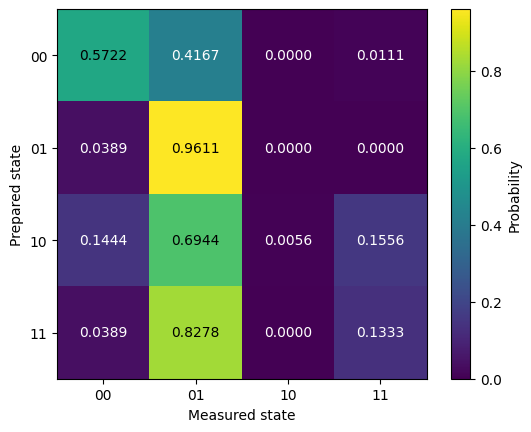

In [1382]:
nro_delta_y = 120
nro_delta_x = 400


prepared_states = []
model.eval()
with torch.no_grad():
    for prepared_state in [0,1,2,3]:
        
        read_outs = np.zeros(len(np.where(Y_data == prepared_state)[0]))
        
        for c,i in enumerate(np.where(Y_data == prepared_state)[0]):
            
            denom = torch.arange(1, 500+1, dtype=torch.float32).view(1,1,  500)
            x = torch.tensor(X_data[i, :, :500], dtype=torch.float32).unsqueeze(0)
            x = (x / denom).contiguous()
            out_real,pred_real = model(x)
            # print(pred_real)
            
            read_outs[c] = pred_real.item()
        
        
        prepared_states.append(read_outs)
            
            
            
state_matrix = np.zeros((4,4))
    
for prepped_state in range(4):
    for ro_state in range(4):
        state_matrix[prepped_state,ro_state] = np.sum(prepared_states[prepped_state] == ro_state)/prepared_states[prepped_state].shape[0]
    
     
        
fig,ax = plt.subplots()       
im = ax.imshow(state_matrix)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
labels = ['00', '01', '10', '11']  # adjust if different ordering

# Axis ticks and labels
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Measured state")
ax.set_ylabel("Prepared state")

# Annotate values inside squares
for i in range(state_matrix.shape[0]):
    for j in range(state_matrix.shape[1]):
        value = state_matrix[i, j]
        ax.text(j, i,
        f"{value:.4f}",
                    ha="center",
                    va="center",
                    color="white" if value < 0.5 else "black")

ax.set_aspect("equal")


In [ ]:
(torch.tensor(X_data[i,:,:300]).unsqueeze(0)/denom).shape
# model(torch.tensor(X_data[i,:,:300]).unsqueeze(0)/denom)

torch.Size([1, 4, 300])